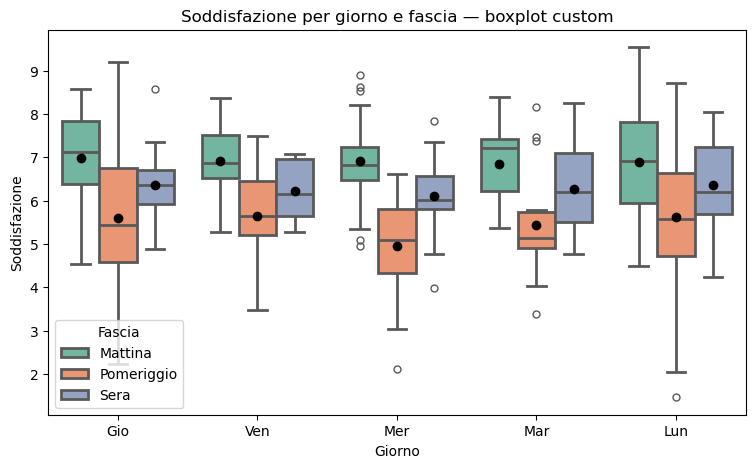

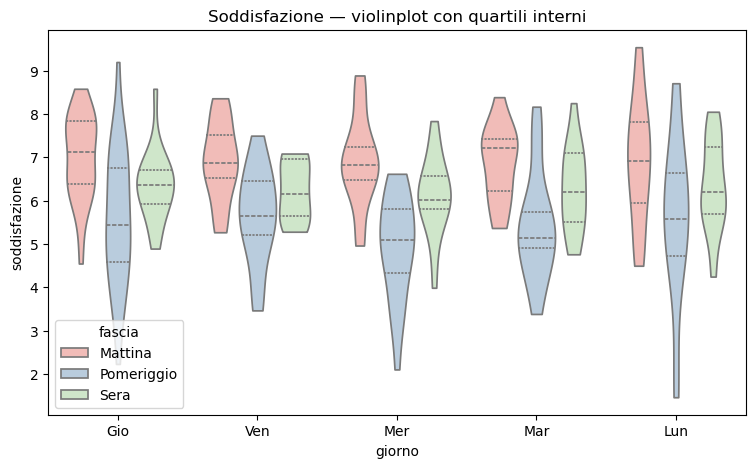

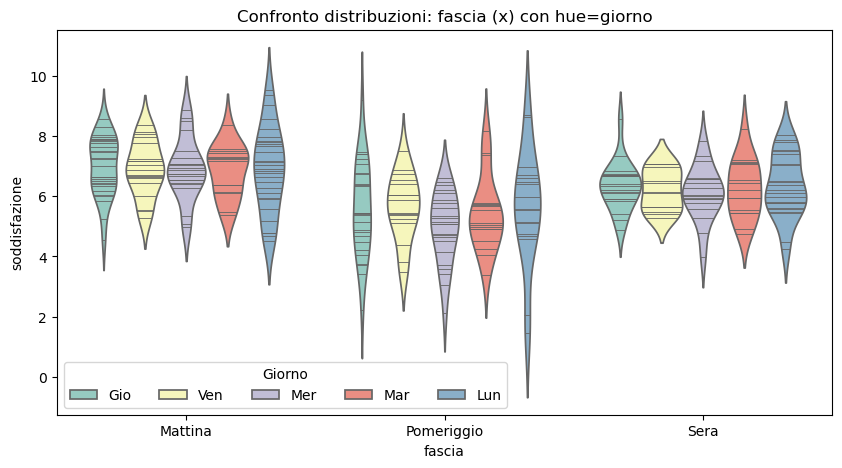

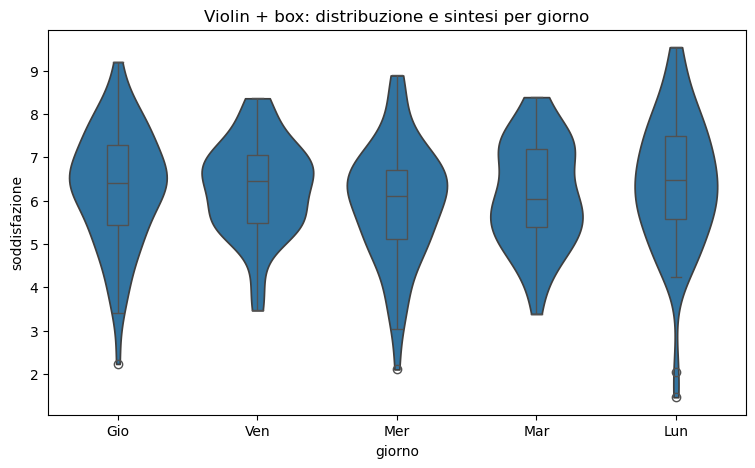

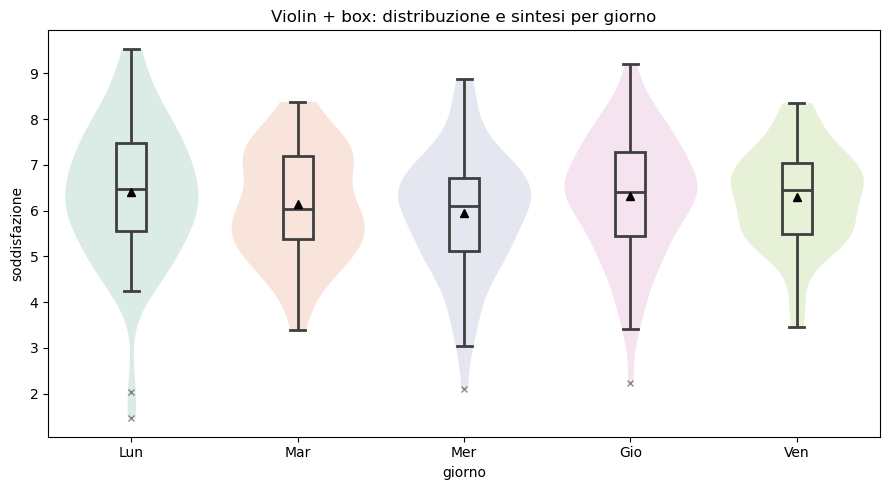

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
giorni = ["Lun", "Mar", "Mer", "Gio", "Ven"]
fasce = ["Mattina", "Pomeriggio", "Sera"]

df = pd.DataFrame({
    "giorno": np.random.choice(giorni, 300),
    "fascia": np.random.choice(fasce, 300),
})

mu = df["fascia"].map({"Mattina": 7, "Pomeriggio": 5.3, "Sera": 6.2}).to_numpy()
sigma = df["fascia"].map({"Mattina": 1.0, "Pomeriggio": 1.4, "Sera": 0.9}).to_numpy()
df["soddisfazione"] = np.clip(np.random.normal(mu, sigma), 0, 10)


plt.figure(figsize=(9,5))
sns.boxplot(
    data=df, x="giorno", y="soddisfazione", hue="fascia",
    palette="Set2", linewidth=2, fliersize=5,
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black"}
)
plt.title("Soddisfazione per giorno e fascia — boxplot custom")
plt.xlabel("Giorno")
plt.ylabel("Soddisfazione")
plt.legend(title="Fascia")
plt.show()


# Esercizio 2 — Violinplot avanzato (quartili + differenze tra fasce)

plt.figure(figsize=(9,5))
sns.violinplot(
    data=df, x="giorno", y="soddisfazione", hue="fascia",
    inner="quartile", cut=0, palette="Pastel1"
)
plt.title("Soddisfazione — violinplot con quartili interni")
plt.show()


# - Esercizio 3 — Confronto categorie multiple con hue + legenda chiara

plt.figure(figsize=(10,5))
sns.violinplot(
    data=df, x="fascia", y="soddisfazione", hue="giorno",
    inner="stick", palette="Set3"
)
plt.title("Confronto distribuzioni: fascia (x) con hue=giorno")
plt.legend(title="Giorno", ncol=5)
plt.show()


# - Esercizio 4 — Grafico combinato violin + box (leggibilità immediata)


plt.figure(figsize=(9,5))
sns.violinplot(data=df, x="giorno", y="soddisfazione", inner=None, cut=0)
sns.boxplot(
    data=df, x="giorno", y="soddisfazione",
    width=0.15, showcaps=True, boxprops={"facecolor":"none"}
)
plt.title("Violin + box: distribuzione e sintesi per giorno")
plt.show()


# Esercizio 4 - rebuild

import matplotlib.pyplot as plt
import seaborn as sns

order = ["Lun", "Mar", "Mer", "Gio", "Ven"]
palette = sns.color_palette("Set2", n_colors=len(order))
day_palette = dict(zip(order, palette))

fig, ax = plt.subplots(figsize=(9, 5))

# 1) SFONDO: violino colorato per giorno (via hue=x)
sns.violinplot(
    data=df,
    x="giorno", y="soddisfazione",
    order=order,
    hue="giorno",
    palette=day_palette,
    dodge=False,     # fondamentale: niente "spostamento" per hue
    inner=None,
    cut=0,
    linewidth=0,
    legend=False,
    ax=ax
)

# (opzionale) rendi i violini più leggeri
for coll in ax.collections:
    coll.set_alpha(0.25)

# 2) OVERLAY: boxplot stretto e trasparente
sns.boxplot(
    data=df,
    x="giorno", y="soddisfazione",
    order=order,
    width=0.18,
    showmeans=True,
    boxprops={"facecolor": "none", "linewidth": 2},
    whiskerprops={"linewidth": 2},
    capprops={"linewidth": 2},
    medianprops={"linewidth": 2},
    meanprops={"marker": "^", "markerfacecolor": "black", "markeredgecolor": "black"},
    flierprops={"marker": "x", "markersize": 5, "alpha": 0.6},
    ax=ax
)

ax.set_title("Violin + box: distribuzione e sintesi per giorno")
ax.set_xlabel("giorno")
ax.set_ylabel("soddisfazione")

plt.tight_layout()
plt.show()